### Imports and settings

In [ ]:
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt
from pathlib import Path
import colorcet as cc
import calendar
import statsmodels.api as sm
from scipy import stats

In [ ]:
datadir = Path().absolute().parent / "evaluation/working"
figdir = Path().absolute().parent / "evaluation/figures"
stationdir = Path().absolute().parent / "evaluation/weatherstationdata/SNAP"
filepattern_ERA5 = 'wind_{airport}_1980_2019_{resolution}.csv'
filepattern_ERA5_2 = 'era5_{airport}_wsp_1981_2020_monthly.csv'
filepattern_station = "alaska_airports_hourly_winds_{ioac}.csv"

In [ ]:
stations = {
    "ANC_PANC": "PANC",
    "FAI_PAFA": "PAFA",
    "UTQ_PABR": "PABR",
    "BTH_PABE": "PABE"
}
locations = {
    "ANC_PANC": "Anchorage",
    "FAI_PAFA": "Fairbanks",
    "UTQ_PABR": "Utqiagvik",
    "BTH_PABE": "Bethel"   
}
startdate = '1980-01-01'
enddate = '2019-12-31'
fullnames = list(stations.keys())
resolutions = ['4km', '12km']
teststation = 'FAI_PAFA'

### Functions

In [ ]:
def get_dataframe_ERA5(station, startdate=startdate, enddate=enddate):
    dfs = {}
    for res in resolutions:
        dfs[res] = pd.read_csv(
            datadir / filepattern_ERA5.format(airport=station, resolution=res))
        dfs[res]['Time'] = pd.to_datetime(dfs[res]['Time'])
        dfs[res].rename(columns={'wspd10': f"wspd10_{res}", 'wdir10': f"wdir10_{res}"}, inplace=True)
        # dfs[res].set_index('Time')
    dfs['4km']['wspd10_12km'] = dfs['12km']['wspd10_12km']
    dfs['4km']['wdir10_12km'] = dfs['12km']['wdir10_12km']
    return dfs['4km']

def get_dataframe_station(station, startdate=startdate, enddate=enddate):
    return pd.read_csv(
        stationdir / filepattern_station.format(ioac=stations[station]))

def get_dataframe(station, startdate=startdate, enddate=enddate):
    ERA5df = get_dataframe_ERA5(station)
    stationdf = get_dataframe_station(station)
    stationdf['ws'] = stationdf['ws'] / 2.237 

    ERA5df.set_index('Time', inplace=True)
    ERA5df.index = pd.to_datetime(ERA5df.index)
    stationdf.set_index('ts', inplace=True)
    stationdf.index = pd.to_datetime(stationdf.index)

    return pd.merge(ERA5df, stationdf,
            how='inner', left_index=True, right_index=True)

In [ ]:
def get_stats(teststation, monthlyDF):
    output = []
    for variable in ('ws', 'wspd10', 'wspd10_4km', 'wspd10_12km'):
        for mth in range(1, 13):
            X = monthlyDF.query(f'month == {mth}')['year']
            Y = monthlyDF.query(f'month == {mth}')[variable]
            slope, _, r_value, p_value, _ = stats.linregress(X, Y)
            mean = Y.mean()
            output.append({
                "location": stations[teststation],
                'variable': variable,
                'month': mth, 
                'mean_monthly_wspd': mean, 
                'trend': slope, 
                'p_value': p_value, 
                'r_value':r_value})
    return output

In [ ]:
def get_monthly(hourlyDF, 
                startdate=startdate, enddate=enddate):
    hourlyDF = hourlyDF.loc[startdate:enddate]
    monthly_avg = hourlyDF[['wspd10_4km', 'wspd10_12km', 'ws']].groupby(
        pd.Grouper(freq='D')).max().groupby(
        pd.Grouper(freq='M')).mean()
    monthly_avg['year'] = monthly_avg.index.year
    monthly_avg['month'] = monthly_avg.index.month
    return monthly_avg

In [ ]:
def add_significance_suffix(p_value):
    if p_value < 0.05:
        return ' (**)'
    elif p_value < 0.1:
        return ' (*)'
    else: return ''

### Single location prototyping

In [ ]:
get_dataframe('FAI_PAFA')

,wspd10_4km,wdir10_4km,wspd10_12km,wdir10_12km,ws,wd
1980-01-01 08:00:00,0.718,359.058,0.502,12.860,1.287439,40.0
1980-01-01 09:00:00,1.311,6.986,0.952,21.372,0.000000,0.0
1980-01-01 10:00:00,1.401,11.591,1.190,30.591,0.000000,0.0
1980-01-01 11:00:00,1.512,18.017,1.409,37.718,1.287439,360.0
1980-01-01 12:00:00,1.486,16.546,1.454,37.885,0.000000,0.0
...,...,...,...,...,...,...
2019-12-30 20:00:00,6.897,231.230,8.258,235.077,3.598570,200.0
2019-12-30 21:00:00,3.143,223.768,4.415,232.713,4.112651,190.0
2019-12-30 22:00:00,2.243,205.161,3.227,230.895,0.000000,0.0
2019-12-30 23:00:00,3.312,244.941,3.709,253.665,2.056325,70.0


In [ ]:
teststation

'FAI_PAFA'

In [ ]:
get_dataframe(teststation)

,wspd10_4km,wdir10_4km,wspd10_12km,wdir10_12km,ws,wd
1980-01-01 08:00:00,0.718,359.058,0.502,12.860,1.287439,40.0
1980-01-01 09:00:00,1.311,6.986,0.952,21.372,0.000000,0.0
1980-01-01 10:00:00,1.401,11.591,1.190,30.591,0.000000,0.0
1980-01-01 11:00:00,1.512,18.017,1.409,37.718,1.287439,360.0
1980-01-01 12:00:00,1.486,16.546,1.454,37.885,0.000000,0.0
...,...,...,...,...,...,...
2019-12-30 20:00:00,6.897,231.230,8.258,235.077,3.598570,200.0
2019-12-30 21:00:00,3.143,223.768,4.415,232.713,4.112651,190.0
2019-12-30 22:00:00,2.243,205.161,3.227,230.895,0.000000,0.0
2019-12-30 23:00:00,3.312,244.941,3.709,253.665,2.056325,70.0


In [ ]:
compDF

,wspd10_4km,wdir10_4km,wspd10_12km,wdir10_12km,ws,wd
1980-01-01 08:00:00,0.718,359.058,0.502,12.860,1.287439,40.0
1980-01-01 11:00:00,1.512,18.017,1.409,37.718,1.287439,360.0
1980-01-01 17:00:00,1.859,12.802,1.615,34.871,1.287439,10.0
1980-01-01 18:00:00,1.741,9.607,1.540,33.522,1.287439,20.0
1980-01-01 20:00:00,1.207,13.715,1.143,44.378,1.287439,350.0
...,...,...,...,...,...,...
2019-12-30 19:00:00,0.906,270.291,0.635,216.276,3.084488,200.0
2019-12-30 20:00:00,6.897,231.230,8.258,235.077,3.598570,200.0
2019-12-30 21:00:00,3.143,223.768,4.415,232.713,4.112651,190.0
2019-12-30 23:00:00,3.312,244.941,3.709,253.665,2.056325,70.0


In [ ]:
compDF = get_dataframe(teststation)
compDF = compDF.loc[compDF.ws > 0]
print(len(compDF))
monthly_DF = get_monthly(compDF)
monthly_undownscaled = pd.read_csv(datadir / filepattern_ERA5_2.format(
    airport=stations[teststation]), skiprows=2)
monthly_DF['wspd10'] = monthly_undownscaled['wsp10'].values 
monthly_DF

211809


/var/folders/jh/dmrl1jcn7ql6ftcyq7l6p8v80000gn/T/ipykernel_78313/1654113850.py:6: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  pd.Grouper(freq='M')).mean()


,wspd10_4km,wspd10_12km,ws,year,month,wspd10
1980-01-31,3.445214,3.712607,3.539977,1980,1,2.886
1980-02-29,3.755172,4.048414,4.812634,1980,2,2.175
1980-03-31,3.019839,3.227323,4.270552,1980,3,2.657
1980-04-30,4.143400,4.454567,6.777231,1980,4,2.620
1980-05-31,5.266774,5.480032,8.155508,1980,5,2.243
...,...,...,...,...,...,...
2019-08-31,4.149419,4.160000,5.074625,2019,8,1.741
2019-09-30,3.341733,3.607600,4.266726,2019,9,2.231
2019-10-31,3.490452,3.881742,4.145673,2019,10,2.320
2019-11-30,3.458667,4.180567,3.924452,2019,11,2.420


In [ ]:
get_stats(teststation, monthly_DF)

[{'location': 'PAFA',
  'variable': 'ws',
  'month': 1,
  'mean_monthly_wspd': 2.7403071990617236,
  'trend': -0.0004725715551829637,
  'p_value': 0.9657403634374495,
  'r_value': -0.007013518158108761},
 {'location': 'PAFA',
  'variable': 'ws',
  'month': 2,
  'mean_monthly_wspd': 3.2971601585499117,
  'trend': -0.0022967103701863954,
  'p_value': 0.8197163390381674,
  'r_value': -0.037202955311243784},
 {'location': 'PAFA',
  'variable': 'ws',
  'month': 3,
  'mean_monthly_wspd': 4.305433664518052,
  'trend': -0.00027618175963348753,
  'p_value': 0.9663640952911081,
  'r_value': -0.0068857565085191355},
 {'location': 'PAFA',
  'variable': 'ws',
  'month': 4,
  'mean_monthly_wspd': 5.189513485322604,
  'trend': 0.0004692388487104885,
  'p_value': 0.958366830857462,
  'r_value': 0.008524203194459188},
 {'location': 'PAFA',
  'variable': 'ws',
  'month': 5,
  'mean_monthly_wspd': 5.892313294014161,
  'trend': -0.01580164153131417,
  'p_value': 0.04073431496060434,
  'r_value': -0.325000

In [ ]:
mth = 8
X = monthly_DF.query(f'month == {mth}')['year']
Y = monthly_DF.query(f'month == {mth}')['ws']
slope, intercept, r_value, p_value, std_err = stats.linregress(X, Y)

In [ ]:
slope, intercept, p_value

(-0.020028839927849037, 44.81017138408087, 0.0003104972875426793)

In [ ]:
cmap = plt.cm.get_cmap('cet_glasbey')
cmap = plt.cm.get_cmap('Set1')

/var/folders/jh/dmrl1jcn7ql6ftcyq7l6p8v80000gn/T/ipykernel_78313/1137458020.py:1: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('cet_glasbey')
/var/folders/jh/dmrl1jcn7ql6ftcyq7l6p8v80000gn/T/ipykernel_78313/1137458020.py:2: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('Set1')


In [ ]:
monthly_DF.index.name = 'Time'
df_forplot = pd.melt(monthly_DF.reset_index(), id_vars=[monthly_DF.index.name, 'year', 'month'], 
        value_vars=['wspd10', 'wspd10_4km', 'wspd10_12km', 'ws'], value_name='wind', var_name=teststation)

In [ ]:
palette = sns.color_palette(cc.b_glasbey_category10, n_colors=3)
palette = sns.color_palette("Set2", 3)
viridis_palette = sns.color_palette("viridis", 25)
viridis_palette = [viridis_palette[ii] for ii in [14, 8, -1]]
viridis_palette

[(0.123444, 0.636809, 0.528763),
 (0.185556, 0.41857, 0.556753),
 (0.906311, 0.894855, 0.098125)]

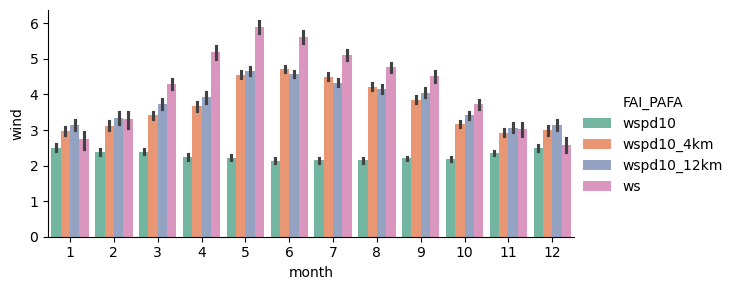

In [ ]:
g = sns.catplot(data=df_forplot, kind="bar", x="month", y="wind", 
            hue=teststation, palette='Set2', width=0.85, height=3, aspect=2)
# g._legend.remove()

In [ ]:
month_abbr = [calendar.month_abbr[ii] for ii in range(1, 13)]
month_initials = [item[0] for item in month_abbr]

NameError: name 'month_abbr' is not defined

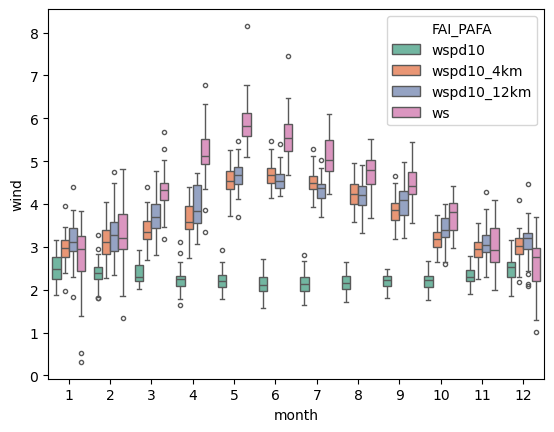

In [ ]:
g = sns.boxplot(data=df_forplot, x="month", y="wind", 
            hue=teststation, palette='Set2', legend=True, fliersize=3)
g.set_xticklabels(month_abbr)
g.set_xlabel('')
g.set_ylabel('hourly wind m/s')
g.set_title(f"teststation - dates with > 0 wind speed")

/var/folders/jh/dmrl1jcn7ql6ftcyq7l6p8v80000gn/T/ipykernel_69546/3866456013.py:1: UserWarning: 
The palette list has fewer values (3) than needed (4) and will cycle, which may produce an uninterpretable plot.
  g = sns.catplot(data=df_forplot, kind="violin", x="month", y="wind",


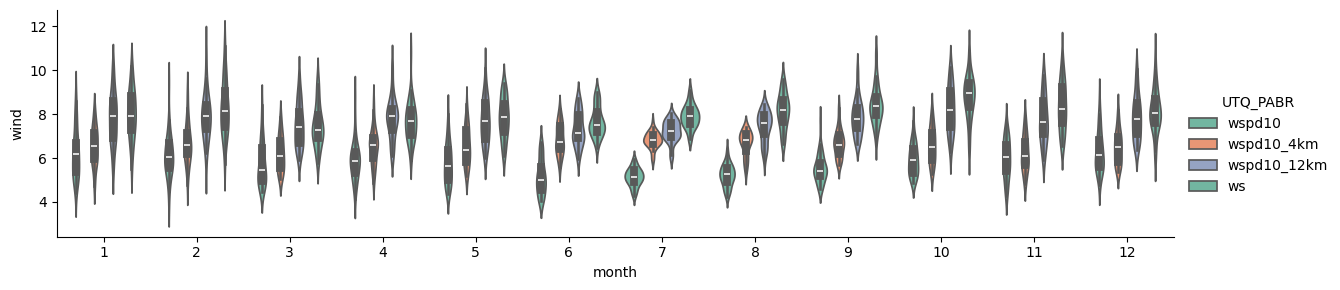

In [ ]:
g = sns.catplot(data=df_forplot, kind="violin", x="month", y="wind", 
            hue=teststation, palette=palette, height=3, aspect=4)


/var/folders/jh/dmrl1jcn7ql6ftcyq7l6p8v80000gn/T/ipykernel_69546/3093682529.py:1: UserWarning: 
The palette list has fewer values (3) than needed (4) and will cycle, which may produce an uninterpretable plot.
  g = sns.catplot(data=df_forplot, kind="violin", x="month", y="wind",


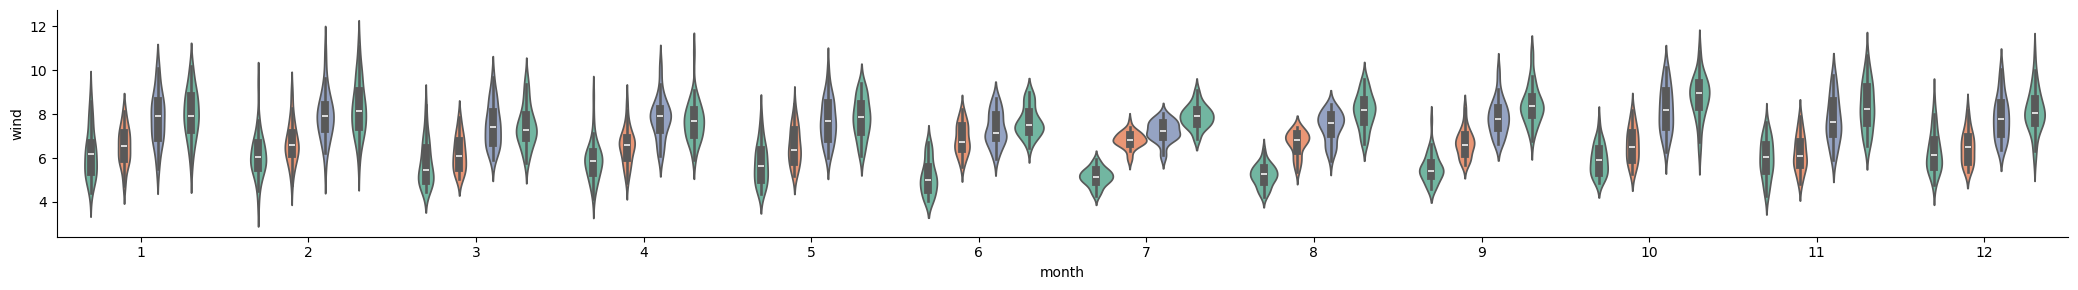

In [ ]:
g = sns.catplot(data=df_forplot, kind="violin", x="month", y="wind", 
            hue=teststation, palette=palette, height=3, aspect=7)
g._legend.remove()

<Axes: xlabel='Time'>

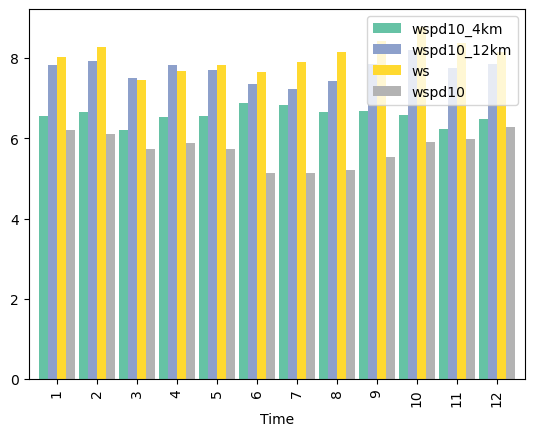

In [ ]:
monthly_DF.drop(columns=['month', 'year']).groupby(monthly_DF.index.month).mean().plot(
    kind='bar', width=0.9, cmap='Set2')

### Make all plots and statistics

/var/folders/jh/dmrl1jcn7ql6ftcyq7l6p8v80000gn/T/ipykernel_69546/1654113850.py:6: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  pd.Grouper(freq='M')).mean()
/var/folders/jh/dmrl1jcn7ql6ftcyq7l6p8v80000gn/T/ipykernel_69546/1570346108.py:19: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  g.set_xticklabels(month_abbr)
/var/folders/jh/dmrl1jcn7ql6ftcyq7l6p8v80000gn/T/ipykernel_69546/1654113850.py:6: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  pd.Grouper(freq='M')).mean()
/var/folders/jh/dmrl1jcn7ql6ftcyq7l6p8v80000gn/T/ipykernel_69546/1570346108.py:19: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  g.set_xticklabels(month_abbr)
/var/folders/jh/dmrl1jcn7ql6ftcyq7l6p8v80000gn/T/ipykernel_69546/1654113850.py:6: FutureWa

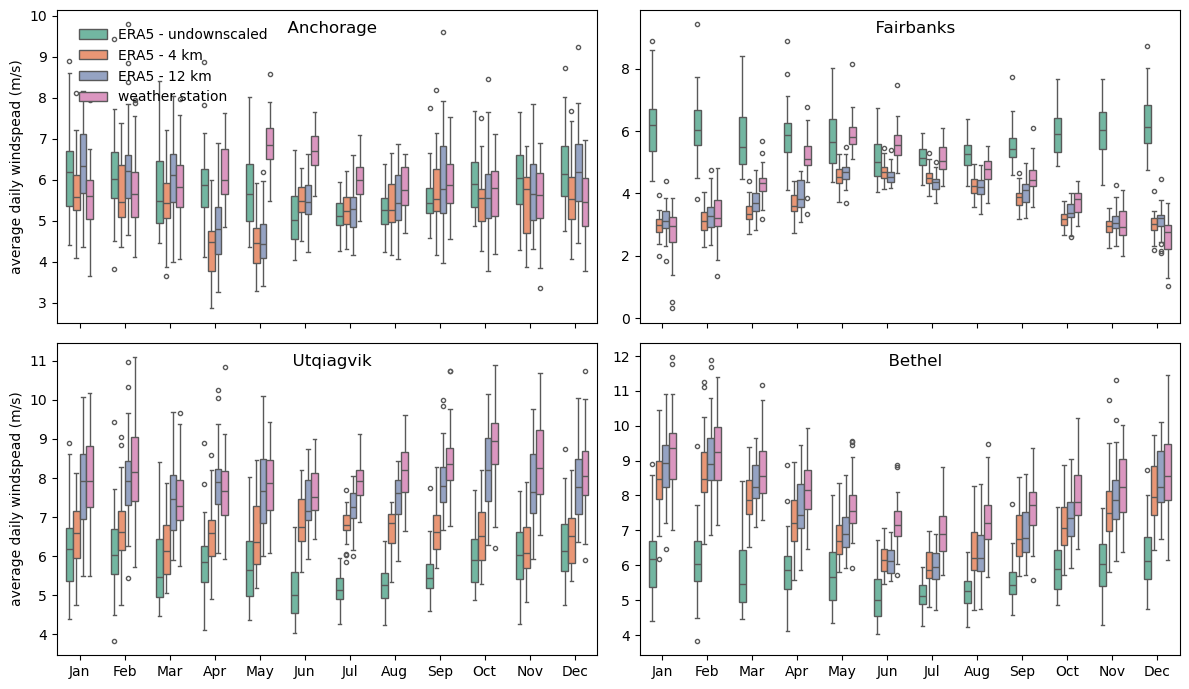

In [ ]:
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(12, 7), sharex=True)

results = []
for ii, (ax, station) in enumerate(zip(axes.flatten(), stations)):
    compDF = get_dataframe(station)
    location = locations[station]
    monthly_DF = get_monthly(compDF, 
                        startdate=startdate, enddate=enddate)
    monthly_undownscaled = pd.read_csv(datadir / filepattern_ERA5_2.format(
    airport=stations[teststation]), skiprows=2)
    monthly_DF['wspd10'] = monthly_undownscaled['wsp10'].values 
    monthly_DF.index.name = 'Time'
    results.extend(get_stats(station, monthly_DF))
    df_forplot = pd.melt(monthly_DF.reset_index(), id_vars=[monthly_DF.index.name, 'year', 'month'], 
        value_vars=['wspd10', 'wspd10_4km', 'wspd10_12km', 'ws'], value_name='wind', var_name=station)
    g = sns.boxplot(data=df_forplot, x="month", y="wind", 
            hue=station, palette="Set2", width=0.6, fliersize=3, ax=ax)
    ax.get_legend().remove()  
    g.set_xticklabels(month_abbr)
    g.set_xlabel('')
    if ii%2:
        g.set_ylabel('')
    else:
        g.set_ylabel('average daily windspead (m/s)')
    ax.set_title('  ' + location, loc='center', y=0.9)
handles, _ = ax.get_legend_handles_labels()
labels = ['ERA5 - undownscaled', 'ERA5 - 4 km', 'ERA5 - 12 km', 'weather station']
fig.legend(handles, labels, loc='upper left', ncol=1, bbox_to_anchor=(0.06, 0.97), frameon=False)
plt.tight_layout()

In [ ]:
fn = f"wind_stations_monthly_distribution_box_{startdate}-{enddate}.png"
fig.savefig(figdir / fn, bbox_inches='tight', dpi=300)

In [ ]:
results = []
for station in stations:
    compDF = get_dataframe(station)
    location = locations[station]
    monthly_DF = get_monthly(compDF, 
                        startdate=startdate, enddate=enddate)
    monthly_DF.index.name = 'Time'
    results.extend(get_stats(station, monthly_DF))

/var/folders/jh/dmrl1jcn7ql6ftcyq7l6p8v80000gn/T/ipykernel_3995/1654113850.py:6: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  pd.Grouper(freq='M')).mean()
/var/folders/jh/dmrl1jcn7ql6ftcyq7l6p8v80000gn/T/ipykernel_3995/1654113850.py:6: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  pd.Grouper(freq='M')).mean()
/var/folders/jh/dmrl1jcn7ql6ftcyq7l6p8v80000gn/T/ipykernel_3995/1654113850.py:6: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  pd.Grouper(freq='M')).mean()
/var/folders/jh/dmrl1jcn7ql6ftcyq7l6p8v80000gn/T/ipykernel_3995/1654113850.py:6: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  pd.Grouper(freq='M')).mean()


In [ ]:
resultsDF = pd.DataFrame.from_records(results)
resultsDF

,location,variable,month,mean_monthly_wspd,trend,p_value,r_value
0,PANC,ws,1,5.579380,-0.039072,0.000065,-0.588398
1,PANC,ws,2,5.712088,-0.046223,0.000171,-0.560154
2,PANC,ws,3,5.892847,-0.014684,0.175383,-0.218591
3,PANC,ws,4,6.134023,-0.014286,0.124031,-0.247237
4,PANC,ws,5,6.836781,-0.002189,0.811044,-0.039025
...,...,...,...,...,...,...,...
139,PABE,wspd10_12km,8,6.322330,-0.012712,0.213657,-0.200986
140,PABE,wspd10_12km,9,6.949668,-0.015849,0.168385,-0.222099
141,PABE,wspd10_12km,10,7.353198,0.009873,0.388272,0.140183
142,PABE,wspd10_12km,11,7.911085,0.002700,0.855340,0.029763


In [ ]:
tableDF = resultsDF.query('variable != "ERA5-12km"')
tableDF['ID'] = tableDF.location + ': ' + tableDF['variable']
tableDF['strtrend'] = tableDF['trend'].round(2).astype(str) 
tableDF['sigtrend'] = tableDF['strtrend'] + tableDF['p_value'].apply(add_significance_suffix)


In [ ]:
sigtable = tableDF.pivot(index='ID', columns='month', values='sigtrend')
sigtable.columns = [calendar.month_abbr[ii] for ii in sigtable.columns]
sigtable

,Jan,Feb,Mar,Apr,May,Jun,Jul,Aug,Sep,Oct,Nov,Dec
ID,,,,,,,,,,,,
PABE: ws,0.01,0.0,-0.02 (*),0.0,0.01,-0.0,0.01,0.0,-0.0,-0.0,0.0,0.0
PABE: wspd10_12km,-0.0,0.02,-0.02 (**),0.01,-0.0,-0.0,-0.0,-0.01,-0.02,0.01,0.0,-0.02
PABE: wspd10_4km,-0.01,0.01,-0.02 (**),0.0,-0.0,-0.0,-0.0,-0.01,-0.02,0.01,0.0,-0.02
PABR: ws,0.02,0.04 (**),0.01,0.01,-0.0,0.01,0.0,-0.01,-0.01,0.04 (**),0.05 (**),0.02
PABR: wspd10_12km,-0.01,0.02,0.01,0.01,-0.01,0.01,0.01 (*),0.01,-0.0,0.05 (**),0.01,-0.01
PABR: wspd10_4km,-0.0,0.02,0.01,0.01,-0.0,0.01,0.0,0.0,-0.01,0.03 (**),0.0,-0.01
PAFA: ws,-0.0,-0.0,-0.0,0.0,-0.02 (**),-0.02 (**),-0.02 (**),-0.02 (**),-0.02 (**),-0.01 (*),0.0,0.01
PAFA: wspd10_12km,-0.01,-0.0,-0.01,0.01,-0.0,-0.0,-0.0,-0.01 (*),-0.01,-0.0,0.0,-0.0
PAFA: wspd10_4km,-0.01,-0.0,-0.0,0.01,0.0,-0.0,-0.0,-0.01 (*),-0.0,-0.0,0.0,0.0
